In [ ]:
# This code defines the functions to simulated XRD and M-H datasets for iron oxide nanoparticles
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import k, mu_0, pi
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import XRDCalculator

# Load CIF structures 
fe3o4_struct = Structure.from_file("1010369_Fe3O4.cif")
feo_struct   = Structure.from_file("1011169_FeO.cif")
alphaFe2O3_struct   = Structure.from_file("1011240_Hematite.cif") # not used currently


# Simulated normalized XRD for Fe3O4/FeO mixing using scherrer broadening for each phase, intrumental broadening (in quadrature) and Pseudo-Voigt peak shapes
def simulate_xrd_fe3o4_feo(grain_size_fe3o4_nm,
                           grain_size_feo_nm,
                           phase_frac_fe3o4,
                           two_theta_range=(25, 65),
                           num_points=2000,
                           K=0.9,
                           wavelength=1.5406,
                           instr_fwhm_deg=0.02): 
    
    
    calc = XRDCalculator(wavelength="CuKa")
    two_theta = np.linspace(*two_theta_range, num_points)
    intensity = np.zeros_like(two_theta)

    # Define mapping from structure to size and phase fraction
    phases = [
        (fe3o4_struct, phase_frac_fe3o4, grain_size_fe3o4_nm),
        (feo_struct,   1 - phase_frac_fe3o4, grain_size_feo_nm)
    ]

    for struct, frac, gs_nm in phases:
        pat = calc.get_pattern(struct, two_theta_range=two_theta_range)
        D_A = gs_nm * 10.0  # convert nm to anstrom
        for x0, I0 in zip(pat.x, pat.y):
            theta0 = np.radians(x0 / 2)
            # Scherrer size broadening
            beta_size_rad = (K * wavelength) / (D_A * np.cos(theta0))
            beta_size_deg = beta_size_rad * 180 / np.pi
            # Total FWHM
            beta_total = np.sqrt(beta_size_deg**2 + instr_fwhm_deg**2)
            # Pseudo-Voigt
            sigma_G = beta_total / (2 * np.sqrt(2 * np.log(2)))
            gamma_L = beta_total / 2
            eta = 0.3 #Gaussian and Lorentzian mixing parameter
            diff = two_theta - x0
            G = np.exp(-diff**2 / (2 * sigma_G**2)) / (sigma_G * np.sqrt(2 * np.pi))
            L = (1 / np.pi) * (gamma_L / (diff**2 + gamma_L**2))
            
            intensity += frac * I0 * (eta * L + (1 - eta) * G)

    # Normalize to max = 1
    intensity /= intensity.max()
    return two_theta, intensity

# Simulate Langevin model for Fe3O4, surface effect/ spin canting for scaling Ms(D), linear paramagnetic FeO contribution, returns field array (T) and total magnetization in (Am^2/kg)
def simulate_hysteresis_langevin(grain_size_nm,
                                      phase_frac_fe3o4,
                                      spin_canting_layer_nm=0.3, # Could be tuned depending on experimental data
                                      chi_mass=1e-6,
                                      T=300.0,
                                      B_min=-2.8,
                                      B_max=2.8,
                                      n_points=300):

    # Size-dependent Ms via core–shell surface layer
    Ms_bulk = 92.0  # Am^2/kg
    d, t = grain_size_nm, spin_canting_layer_nm
    Ms_size = 0.0 if d <= 2*t else Ms_bulk * ((d - 2*t)/d)**3

    # Paramagnetic FeO 
    slope_para = chi_mass/ mu_0

    # Effective moment per particle
    r      = 0.5 * d * 1e-9         # radius in m
    V      = (4/3) * pi * r**3      # volume in m^3
    rho    = 5220.0                 # kg/m^3
    m_p    = rho * V                # kg
    mu_eff = Ms_size * m_p          # Am^2

    # Field grid
    B = np.linspace(B_min, B_max, n_points)

    # Langevin function
    alpha = mu_eff * B / (k * T)
    L = np.zeros_like(alpha)
    mask = np.abs(alpha) > 1e-8
    L[mask] = 1/np.tanh(alpha[mask]) - 1/alpha[mask]

    # Mixed phased magnetization
    M_spm  = phase_frac_fe3o4 * Ms_size * L
    M_para = (1 - phase_frac_fe3o4) * slope_para * B
    M_tot  = M_spm + M_para

    return B, M_tot

In [ ]:
# This code plots XRD and M-H datsasets that can be generated from the simulation functions

import matplotlib.pyplot as plt

# Sample parameters 
grain_size_fe3o4 = 5 # Fe3O4 grain size in nm
grain_size_feo   = 10 # FeO grain size in nm 
phase_frac       = 0.0 # fraction of Fe3O4 (0-1)

# Simulate XRD
two_theta, xrd_intensity = simulate_xrd_fe3o4_feo(
    grain_size_fe3o4_nm=grain_size_fe3o4,
    grain_size_feo_nm=grain_size_feo,
    phase_frac_fe3o4=phase_frac
)

# Simulate Langevin-paramagnetic M–H curve
B_field, M_curve = simulate_hysteresis_langevin(
    grain_size_nm=grain_size_fe3o4,
    phase_frac_fe3o4=phase_frac
)

# Plot side by side 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Font size parameters
label_fontsize = 16
tick_fontsize = 14
title_fontsize = 16

# XRD plot
ax1.plot(two_theta, xrd_intensity, lw=2.0, color='tab:blue')
ax1.set_xlabel('2θ (degrees)', fontsize=label_fontsize)
ax1.set_ylabel('Normalized Intensity (arb. units)', fontsize=label_fontsize)
ax1.set_title(
    f'Fe₃O₄ {phase_frac*100:.0f}% ({grain_size_fe3o4:.0f} nm), '
    f'FeO {(1-phase_frac)*100:.0f}% ({grain_size_feo:.0f} nm)',
    fontsize=title_fontsize
)
ax1.set_xticks([25, 30, 35, 40, 45, 50, 55, 60, 65])
ax1.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
ax1.tick_params(axis='both', labelsize=tick_fontsize)
ax1.grid(True)

# M–H plot
ax2.plot(B_field, M_curve, lw=2.0, color='tab:red')
ax2.set_xlabel('Magnetic Field (T)', fontsize=label_fontsize)
ax2.set_ylabel('Magnetization (Am$^2$/kg)', fontsize=label_fontsize)
ax2.set_title(
    f'Fe₃O₄ {phase_frac*100:.0f}% ({grain_size_fe3o4:.0f} nm), '
    f'FeO {(1-phase_frac)*100:.0f}% ({grain_size_feo:.0f} nm)',
    fontsize=title_fontsize
)
ax2.tick_params(axis='both', labelsize=tick_fontsize)
ax2.set_xticks([-3, -1.5, 0, 1.5, 3])
ax2.grid(True)

# Seperate plots

# XRD plot
plt.figure(figsize=(6, 5))
plt.plot(two_theta, xrd_intensity, lw=2, color="b", alpha = 1.0)
plt.xlabel("2θ (degrees)", fontsize=16)
plt.ylabel("Normalized Intensity (arb. units)", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.title("FeO", fontsize=16)
#plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# M-H plot
plt.figure(figsize=(6, 5))
plt.plot(B_field, M_curve, lw=2, color="r")
plt.xlabel("Magnetic Field (T)", fontsize=16)
plt.ylabel("Magnetization (Am$^2$/kg)", fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
#plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# XRD curve only, for workflow schematic 
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(two_theta, xrd_intensity, lw=2, color="b")

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_facecolor("white")
fig.patch.set_facecolor("white")

plt.tight_layout()
# fig.savefig("xrd_curve_only.png", dpi=300, bbox_inches="tight")
plt.show()

# Minimal M–B curve only
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(B_field, M_curve, lw=2, color="r")

# Remove everything except the curve
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")
ax.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_facecolor("white")
fig.patch.set_facecolor("white")

plt.tight_layout()
# fig.savefig("mh_curve_only.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Generates simulated dataset of size N, .npz stores full data json does not store full M-B

import json

# Dataset size
N = 20

# Sample random parameters 
grain_sizes_fe3o4 = np.random.uniform(3.0, 50.0, size=N)  # Fe3O4 grain/crystallite size (nm)
grain_sizes_feo   = np.random.uniform(3.0, 50.0, size=N)  # FeO grain/crystallite size (nm)
phase_fracs       = np.random.uniform(0.0, 1.0, size=N)   # Fe3O4 fraction 

# Grid sizes
theta_grid, _ = simulate_xrd_fe3o4_feo(
    grain_size_fe3o4_nm=grain_sizes_fe3o4[0],
    grain_size_feo_nm=  grain_sizes_feo[0],
    phase_frac_fe3o4=  phase_fracs[0]
)
n_xrd = theta_grid.size

B_grid, _ = simulate_hysteresis_langevin(
    grain_size_nm=      grain_sizes_fe3o4[0],
    phase_frac_fe3o4=   phase_fracs[0]
)
n_hyst = B_grid.size

# Preallocate storage 
xrd_data = np.zeros((N, n_xrd), dtype=np.float32)
mh_data  = np.zeros((N, n_hyst), dtype=np.float32)

# labels: [D_Fe3O4, D_FeO, frac_Fe3O4, max_M]
labels   = np.zeros((N, 4), dtype=np.float32)

# Generate dataset 
for i in range(N):
    d1 = grain_sizes_fe3o4[i]
    d2 = grain_sizes_feo[i]
    f  = phase_fracs[i]

    # XRD simulation
    _, I = simulate_xrd_fe3o4_feo(
        grain_size_fe3o4_nm = d1,
        grain_size_feo_nm = d2,
        phase_frac_fe3o4 = f
    )
    xrd_data[i, :] = I

    # M vs. H simulation
    _, M = simulate_hysteresis_langevin(
        grain_size_nm=    d1,
        phase_frac_fe3o4= f
    )
    mh_data[i, :] = M

    # Store labels
    labels[i, 0] = d1          # Fe3O4 size
    labels[i, 1] = d2          # FeO size
    labels[i, 2] = f           # Fe3O4 fraction
    labels[i, 3] = M.max()     # Max magnetization/ magnetization at 3T

# Save data
np.savez('fe3o4_feo_dataset_N_20.npz',
         two_theta=theta_grid,
         B_field=B_grid,
         xrd=xrd_data,
         M_hysteresis=mh_data,
         labels=labels)

print(f"Saved {N} samples to fe3o4_feo_dataset_N_20.npz")

# Save data as JSON
json_path = f"fe3o4_feo_dataset_N_{N}.json"

samples = []
for i in range(N):
    samples.append({
        "id": int(i),
        "xrd": xrd_data[i].tolist(),
        "labels": {
            "D_Fe3O4_nm": float(labels[i, 0]),
            "D_FeO_nm":   float(labels[i, 1]),
            "frac_Fe3O4": float(labels[i, 2]),
            "max_M":      float(labels[i, 3]),
        }
    })

payload = {
    "two_theta": theta_grid.tolist(),
    "samples": samples
}

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

In [ ]:
# Visulization of datasets

import numpy as np
import matplotlib.pyplot as plt

# Load simulate data
data = np.load('fe3o4_feo_dataset_N_25.npz')
labels = data['labels']
# columns: [D_Fe3O4, D_FeO, frac_Fe3O4, M]
grain_sizes_fe3o4 = labels[:, 0]
fe3o4_fractions   = labels[:, 2]
M_values          = labels[:, 3]

# Plot Magnetization at 2.8 T vs. Fe3O4 crystallite size
plt.figure(figsize=(6, 5))
plt.scatter(grain_sizes_fe3o4, M_values, c="b", edgecolors='k', alpha=0.7)
plt.xlabel('Crystallite Size (nm)', fontsize=16)
plt.ylabel('Max Magnetization (Am²/kg)', fontsize=16)
plt.title('N = 1000', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

# Plot Magnetization vs. Fe3O4 phase fraction
plt.figure(figsize=(6, 5))
plt.scatter(fe3o4_fractions, M_values, c="r", edgecolors='k', alpha=0.7)
plt.xlabel('Phase Fraction of Fe$_3$O$_4$', fontsize=16)
plt.ylabel('Max Magnetization (Am²/kg)', fontsize=16)
plt.title('N = 1000', fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [ ]:
# Trains a random forest regression model using the simulated dataset

import numpy as np
import matplotlib.pyplot as plt
import joblib
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#  Load simulated dataset
data = np.load('fe3o4_feo_dataset_N_1000.npz') 
X = data['xrd'] # shape (N, n_xrd)
y = data['labels'][:, 3] # max magnetization 

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,      
    max_features=0.3,  # v1 0.3, v2 sqrt, v3 0.05  
    random_state=1,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

# Compute metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Plot predicted vs. actual 
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, c="b", alpha=0.7, edgecolor='k')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Ideal')
plt.xlabel('Actual Max Magnetization (Am$^2$/kg)', fontsize=16)
plt.ylabel('Predicted Max Magnetization (Am$^2$/kg)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('Random Forest Model: N = 1000', fontsize=16)

textstr = '\n'.join((
    f'$R^2 = {r2:.3f}$',
    f'MAE = {mae:.3f} Am$^2$/kg',
    f'RMSE = {rmse:.3f} Am$^2$/kg',
))
plt.text(0.05, 0.975, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=1.0))

legend = plt.legend(loc='upper left', bbox_to_anchor=(0.1, 0.8),
                    fontsize=12, frameon=True)

frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_alpha(1.0)
frame.set_linewidth(1.0)
frame.set_boxstyle("round,pad=0.5") 

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save the trained model as .pkl
model_path = 'rf_model_fe3o4_feo_dataset_N_1000_v2_repeat.pkl'
joblib.dump(rf, model_path)
print(f"Random Forest model saved to {model_path}")

In [ ]:
# Trains a gradient boosting regression model using the simulated dataset

import numpy as np
import matplotlib.pyplot as plt
import joblib
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load simulated dataset
data = np.load('fe3o4_feo_dataset_N_1000.npz')       
X = data['xrd'] # shape (N, n_xrd)
y = data['labels'][:, 3] # Max Magnetization

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Train Gradient Boosting

# v1 conditions
#gb = GradientBoostingRegressor(
#        n_estimators=500,
#        learning_rate=0.05,
#        max_depth=3,
#        random_state=1)

# v2 conditions
#gb = GradientBoostingRegressor(
#    n_estimators=500,
#    learning_rate=0.05,
#    max_depth=3,
#    subsample=0.8,        
#    min_samples_leaf=5,   
#    random_state=1
#)

# v3/v4 conditions
gb = GradientBoostingRegressor(
    n_estimators=800,          #
    learning_rate=0.03,        
    # tree shape / regularization
    max_depth=3,
    min_samples_leaf=5,
    max_features="sqrt",       # v5 0.3 v3 "sqrt"
    subsample=0.8,          
    loss="huber",              # v3"huber" or v4"squared_error" 
    alpha=0.9,                 # Huber’s quantile
    # gentle early stopping to prevent overfitting
    validation_fraction=0.1,   # uses 10% of training data as dev set
    n_iter_no_change=20,       # stop if no dev improvement
    tol=1e-4,
    random_state=1
)

gb.fit(X_train, y_train)

# Predict on test set
y_pred = gb.predict(X_test)

# Compute metrics
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Plot predicted vs. actual
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, c="b", alpha=0.7, edgecolor='k')

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Ideal') 
plt.xlabel('Actual Max Magnetization (Am$^2$/kg)', fontsize=16)
plt.ylabel('Predicted Max Magnetization (Am$^2$/kg)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('Gradient Boosting Model: N = 1000', fontsize=16)

textstr = '\n'.join((
    f'$R^2 = {r2:.3f}$',
    f'MAE = {mae:.3f} Am$^2$/kg',
    f'RMSE = {rmse:.3f} Am$^2$/kg',
))
plt.text(0.05, 0.975, textstr, transform=plt.gca().transAxes,
         fontsize=12, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=1.0))

legend = plt.legend(loc='upper left', bbox_to_anchor=(0.1, 0.8),
                    fontsize=12, frameon=True)
frame = legend.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_alpha(1.0)
frame.set_linewidth(1.0)
frame.set_boxstyle("round,pad=0.5")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save the trained model
model_path = 'gb_model_fe3o4_feo_dataset_N_1000_v3_repeat.pkl'
joblib.dump(gb, model_path)
print(f"Gradient Boosting model saved to {model_path}")

In [ ]:
# Analyze the feature importance be considering the change in R^2 with permuation of 2theta values

import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

# Load simulated Fe3O4-FeO dataset
data = np.load('fe3o4_feo_dataset_N_1000.npz')
X = data['xrd'] # shape (N, n_xrd)
y = data['labels'][:, 3] # Max magnetization
two_theta = data['two_theta'] # 2theta values from simulation grid

# Check feature count
assert X.shape[1] == two_theta.shape[0], (
    f"Feature count ({X.shape[1]}) must match two_theta length ({two_theta.shape[0]})."
)

# Train/test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,      
    max_features="sqrt",  # v1 0.3, v2 sqrt, v3 0.05  
    random_state=1,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

# Baseline scores for context
train_r2 = rf.score(X_train, y_train)
test_r2  = rf.score(X_test, y_test)
print(f"Train R^2: {train_r2:.4f} | Test R^2: {test_r2:.4f}")

# Compute permutation importance
print("Computing permutation importance...")
result = permutation_importance(
    rf, X_test, y_test, n_repeats=30, random_state=1, n_jobs=-1
)

imp_mean = result.importances_mean
imp_std  = result.importances_std

# Plot Feature Importance
plt.figure(figsize=(6, 5))
plt.plot(two_theta, imp_mean, lw=2, color="b", label='Mean ΔR²')
plt.fill_between(
    two_theta,
    imp_mean - imp_std,
    imp_mean + imp_std,
    color="b", alpha=0.3, label='±1σ'
)
plt.axhline(0.0, color='k', lw=1, alpha=0.6)
plt.xlabel(r"2θ (degrees)", fontsize=14)
plt.ylabel("Permutation importance, ΔR²", fontsize=14)
plt.xticks(fontsize=12)
plt.xlim(25, 65)
plt.yticks(fontsize=12)
plt.title("Random Forest Model: N = 1000", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Save RF model
out_dir = Path(".")
model_path = out_dir / 'rf_model_fe3o4_feo_dataset_N_1000_v2_features.pkl'
joblib.dump(rf, model_path)
print(f"Random Forest model saved to {model_path}")

# Save importances
np.savez(
    out_dir / "rf_perm_importance_N_1000_v2.npz",
    two_theta=two_theta,
    importances_mean=imp_mean,
    importances_std=imp_std,
    train_r2=train_r2,
    test_r2=test_r2,
)

In [ ]:
# Analyze the feature importance be considering the change in R^2 with permuation of 2theta values

import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance

# Load simulated dataset
data = np.load("fe3o4_feo_dataset_N_1000.npz")
X = data["xrd"] # (N, n_xrd)
y = data["labels"][:, 3] # Max magnetization
two_theta = data["two_theta"] # 2theta values from simulation grid

# Check feature count
assert X.shape[1] == two_theta.shape[0], (
    f"Feature count ({X.shape[1]}) must match two_theta length ({two_theta.shape[0]})."
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

# Train Gradient Boosting

# v1 conditions
#gb = GradientBoostingRegressor(
#        n_estimators=500,
#        learning_rate=0.05,
#        max_depth=3,
#        random_state=1)

# v2 conditions
#gb = GradientBoostingRegressor(
#    n_estimators=500,
#    learning_rate=0.05,
#    max_depth=3,
#    subsample=0.8,        
#    min_samples_leaf=5,   
#    random_state=1
#)

# v3/v4 conditions
gb = GradientBoostingRegressor(
    n_estimators=800,          #
    learning_rate=0.03,        
    # tree shape / regularization
    max_depth=3,
    min_samples_leaf=5,
    max_features=0.3,  # v5 0.3   v3 "sqrt"
    subsample=0.8,          
    loss="huber",              # v3"huber" or v4"squared_error" 
    alpha=0.9,                 # Huber’s quantile
    # gentle early stopping to prevent overfitting
    validation_fraction=0.1,   # uses 10% of training data as dev set
    n_iter_no_change=20,       # stop if no dev improvement
    tol=1e-4,
    random_state=1
)

gb.fit(X_train, y_train)

train_r2 = gb.score(X_train, y_train)
test_r2  = gb.score(X_test, y_test)
print(f"Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")

# Permutation importance
print("Computing permutation importance...")
result = permutation_importance(
    gb, X_test, y_test, n_repeats=30, random_state=1, n_jobs=-1
)

imp_mean = result.importances_mean
imp_std  = result.importances_std

# Plot Feature Importance
plt.figure(figsize=(6, 5))
plt.plot(two_theta, imp_mean, lw=2, color="b", label='Mean ΔR²')
plt.fill_between(
    two_theta,
    imp_mean - imp_std,
    imp_mean + imp_std,
    color="b", alpha=0.3, label='±1σ'
)
plt.axhline(0.0, color='k', lw=1, alpha=0.6)

plt.xlabel(r"2θ (degrees)", fontsize=14)
plt.ylabel("Permutation importance, ΔR²", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title("Gradient Boosting Model: N = 1000", fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Save model
out_dir = Path(".")
model_path = out_dir / 'gb_model_fe3o4_feo_dataset_N_1000_v5_features.pkl'
joblib.dump(gb, model_path)
print(f"Gradient Boosting model saved to {model_path}")

# Save importances
np.savez(
    out_dir / "gb_perm_importance_N_1000_v5.npz",
    two_theta=two_theta,
    importances_mean=imp_mean,
    importances_std=imp_std,
    train_r2=train_r2,
    test_r2=test_r2,
)


In [ ]:
# Random Forest: XRD to full M-B curve
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load simulated dataset
DATA_PATH = Path("fe3o4_feo_dataset_N_1000.npz") 
data = np.load(DATA_PATH)

if "xrd" not in data or "M_hysteresis" not in data:
    raise KeyError("Dataset must contain 'xrd' (N,n_xrd) and 'M_hysteresis' (N,n_hyst).")
if "B_field" not in data:
    raise KeyError("Dataset must contain 'B_field' (n_hyst,) for the per-field metric plot.")

X         = data["xrd"] # (N, n_xrd)
Y         = data["M_hysteresis"] # (N, n_hyst)
B_field   = data["B_field"]           
two_theta = data.get("two_theta", None)

N, n_xrd  = X.shape
_, n_hyst = Y.shape
print(f"Loaded XRD: {X.shape}, M-B: {Y.shape}")
print(f"B range: {B_field.min():.3g} to {B_field.max():.3g} T | n_hyst points: {n_hyst}")

# Train/test split
TEST_SIZE     = 0.2
RANDOM_STATE  = 1
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Train multi-output Random Forest
rf = RandomForestRegressor(
    n_estimators=500,
    min_samples_leaf=3,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, Y_train)

# Predict on holdout set
Y_pred = rf.predict(X_test)

# Overall metrics 
rmse_overall = np.sqrt(mean_squared_error(Y_test.ravel(), Y_pred.ravel()))
r2_overall   = r2_score(Y_test, Y_pred, multioutput="variance_weighted")
mae_overall  = mean_absolute_error(Y_test.ravel(), Y_pred.ravel())
print(f"Overall (all points):  R^2={r2_overall:.4f}  MAE={mae_overall:.4f}  RMSE={rmse_overall:.4f}  (Am^2/kg)")

# Plot three example curves
FONTS = dict(ax=16, tick=14, legend=12, title=16)
N_PLOT = min(6, Y_test.shape[0])
rng = np.random.default_rng(RANDOM_STATE)
example_idx = rng.choice(Y_test.shape[0], size=N_PLOT, replace=False)

for k, i in enumerate(example_idx, 1):
    plt.figure(figsize=(6, 5))
    plt.plot(B_field, Y_test[i], 'k-',  lw=2, label='True')
    plt.plot(B_field, Y_pred[i], 'r--', lw=2, label='Prediction')
    plt.xlabel("Magnetic Field (T)", fontsize=FONTS["ax"])
    plt.xlim(-3, 3)
    plt.ylabel("Magnetization (Am$^2$/kg)", fontsize=FONTS["ax"])
    #plt.ylim(-90, 90)
    plt.title(f"Holdout M-B data #{i}", fontsize=FONTS["title"])
    plt.grid(alpha=0.3)
    plt.legend(fontsize=FONTS["legend"])
    plt.tick_params(labelsize=FONTS["tick"])
    plt.tight_layout()
    plt.show()

# Per-field metrics vs. magnetic field: R^2, MAE, RMSE
R2_perB   = np.zeros(n_hyst)
MAE_perB  = np.zeros(n_hyst)
RMSE_perB = np.zeros(n_hyst)

for k in range(n_hyst):
    y_true_k = Y_test[:, k]
    y_pred_k = Y_pred[:, k]
    m = np.isfinite(y_true_k) & np.isfinite(y_pred_k)
    if m.sum() >= 2: 
        R2_perB[k]   = r2_score(y_true_k[m], y_pred_k[m])
        MAE_perB[k]  = mean_absolute_error(y_true_k[m], y_pred_k[m])
        RMSE_perB[k] = np.sqrt(mean_squared_error(y_true_k[m], y_pred_k[m]))
    else:
        R2_perB[k]   = np.nan
        MAE_perB[k]  = np.nan
        RMSE_perB[k] = np.nan

# Double y-axis plot
fig, ax_left = plt.subplots(figsize=(10, 6))

# Left axis: R^2
line_r2, = ax_left.plot(B_field, R2_perB, '-o', c="k", lw=2, ms=5, label=r"$R^2$")
ax_left.set_xlabel("Magnetic Field (T)", fontsize=FONTS["ax"])
ax_left.set_ylabel(r"$R^2$", fontsize=FONTS["ax"])
ax_left.tick_params(axis='both', labelsize=FONTS["tick"])
ax_left.grid(alpha=0.3)

# Right axis: MAE and RMSE
ax_right = ax_left.twinx()
line_mae,  = ax_right.plot(B_field, MAE_perB,  '--s', c="b", lw=2, ms=5, label="MAE")
line_rmse, = ax_right.plot(B_field, RMSE_perB, '-.^', c="r", lw=2, ms=5, label="RMSE")
ax_right.set_ylabel("Error (Am$^2$/kg)", fontsize=FONTS["ax"])
ax_right.tick_params(axis='y', labelsize=FONTS["tick"])

plt.title(f"Per Magnetic Field Metrics, Random Forest Model: N={N}", fontsize=FONTS["title"])

# Combined legend
lines  = [line_r2, line_mae, line_rmse]
labels = [l.get_label() for l in lines]
ax_left.legend(lines, labels, fontsize=FONTS["legend"], loc="center left", framealpha=0.9)

plt.tight_layout()
plt.show()

# Save the trained model
MODEL_PATH = Path(f"rf_multioutput_MB_from_XRD_{N}_test.pkl")
joblib.dump(rf, MODEL_PATH)
np.savez(MODEL_PATH.with_suffix(".meta.npz"), B_field=B_field, two_theta=two_theta)
print(f"Saved model -> {MODEL_PATH}")
print(f"Saved grids -> {MODEL_PATH.with_suffix('.meta.npz')}")


[1/5] E1_XRD_bg_sub.csv: true=76.83, RF=77.49, GB=78.49, avg=77.99
[2/5] E2_XRD_bg_sub.csv: true=81.25, RF=71.5, GB=77.45, avg=74.48
[3/5] E3_XRD_bg_sub.csv: true=64.81, RF=66.75, GB=68.67, avg=67.71
[4/5] E4_XRD_bg_sub.csv: true=62.92, RF=62.5, GB=66.37, avg=64.43
[5/5] E5_XRD_bg_sub.csv: true=39.15, RF=40.25, GB=43.45, avg=41.85

Saved results: C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names\predicted_vs_true_maxM.csv


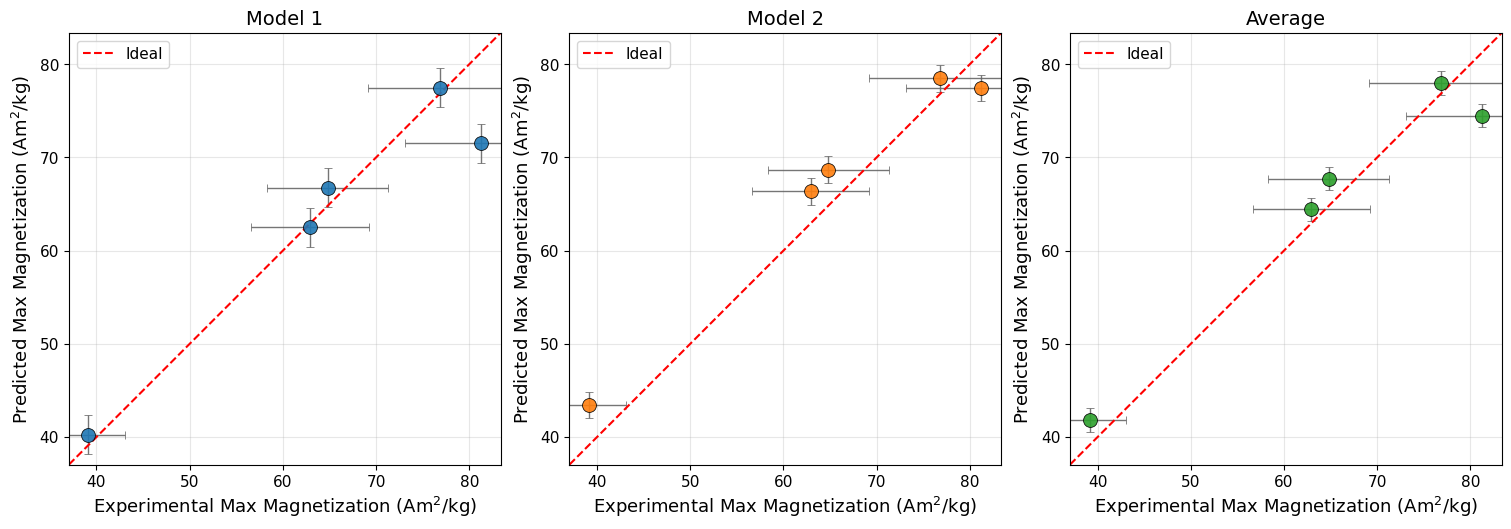

[rf_model_fe3o4_feo_dataset_N_1000_v2]  R^2=0.9066  MAE=2.773  RMSE=4.485  -> R2_MAE_RMSE_rf_model_fe3o4_feo_dataset_N_1000_v2.csv
[gb_model_fe3o4_feo_dataset_N_1000_v3]  R^2=0.9420  MAE=3.413  RMSE=3.535  -> R2_MAE_RMSE_gb_model_fe3o4_feo_dataset_N_1000_v3.csv


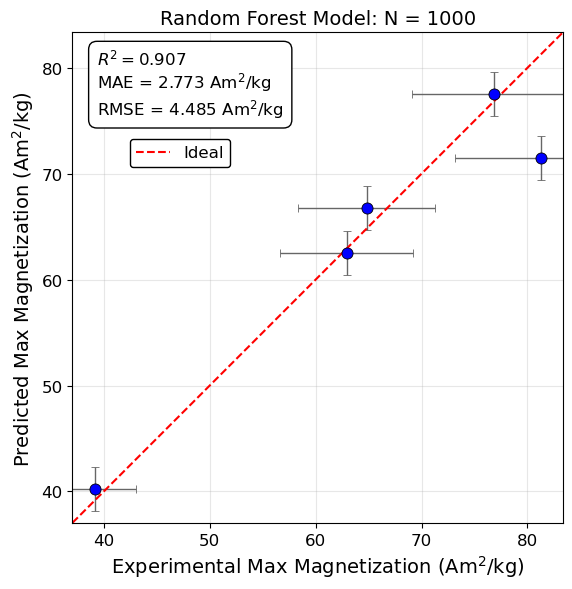

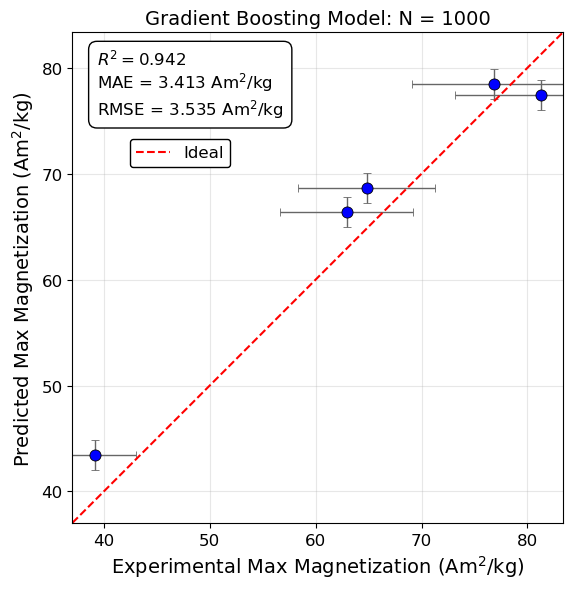

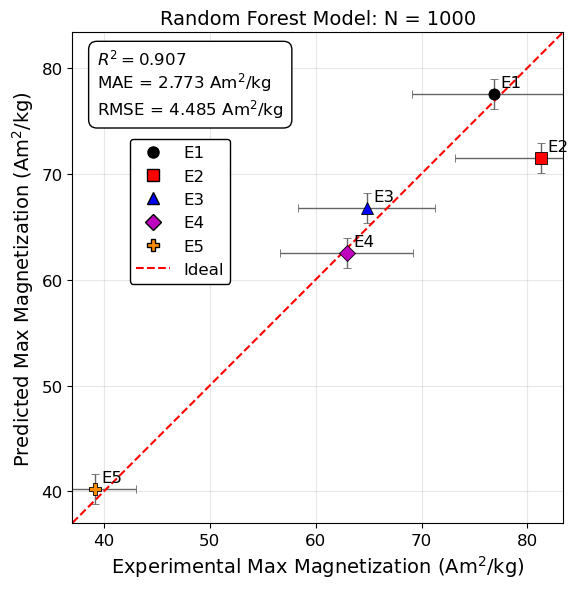

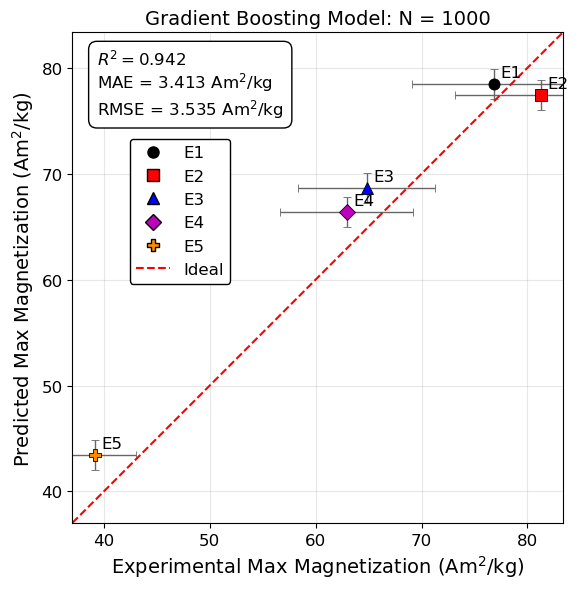

In [16]:
# Batch inference: XRD to predicted max magnetization, and compares to true max magnetization extracted from M-B measurements for each XRD

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from matplotlib.lines import Line2D 


# Inputs

# Paths
XRD_DIR = Path(r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names") # folder containing XRD CSVs
MH_DIR  = Path(r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names") # folder containing M-B CSVs
OUT_DIR = Path(r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\XRD_M-B_datasets_manuscript_names")

# Predicted y-error bars taken as RMSE or MAE on a held-out simulated set, units in (Am^2/kg)
PRED_MAE_MODEL1 = 2.082  
PRED_MAE_MODEL2 = 1.423
# Estimate error in the measurement of magnetic mass used to calculated magnetization, taken as 10%
MASS_REL_ERR    = 0.10   

# File lists 1:1 correspondance
XRD_FILES = [
    r"E1_XRD_bg_sub.csv",
    r"E2_XRD_bg_sub.csv",
    r"E3_XRD_bg_sub.csv",
    r"E4_XRD_bg_sub.csv",
    r"E5_XRD_bg_sub.csv"
]
MH_FILES = [
    r"E1_M-B.csv",
    r"E2_M-B.csv",
    r"E3_M-B.csv",
    r"E4_M-B.csv",
    r"E5_M-B.csv"
]
# Masses in grams for each sample 1:1 correspondance with above files
MASSES_G = [  
    0.0015,
    0.0021,
    0.0033,
    0.0033,
    0.0011
]

# Models and grid sources from simulated training set
MODEL1_PKL  = r"rf_model_fe3o4_feo_dataset_N_1000_v2.pkl"
MODEL2_PKL  = r"gb_model_fe3o4_feo_dataset_N_1000_v3.pkl"
GRID_SOURCE = r"fe3o4_feo_dataset_N_1000.npz" # contains 2theta

# XRD processing params
CLIP_NONNEG    = True # Sets negative values to 0
CROP_TO_GRID   = True # crop raw data to training grid range
NORM_MODE      = "max"

# Loading M-B datafiles, specifcally for QD VersaLab
# magnetic field (Oe) starts in column D row 36, magnetic moment (emu) in column E row 36
MH_START_ROW = 35        # row 36 in Excel
MH_COL_FIELD = 3         # column D
MH_COL_MOM   = 4         # column E
USE_ABS_MAX  = False     # if True, uses max absolute value; else uses max(M) (there is minimal difference)

# Plot settings
DOT_SIZE = 45
FIGSIZE  = (15, 5)
FONTS    = dict(ax=13, tick=11, legend=11, title=14)

# Sample labels and colors for annotated scatter
LEGEND_LABELS = ["E1", "E2", "E3", "E4", "E5"]
COLORS_MB     = ["k", "r", "b", "m", "darkorange"]

#COLORS_MB     = COLORS = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#999999"]

# shape markers for the five samples
MARKERS = ["o", "s", "^", "D", "P"]


# Loading and csv reader functions
def load_two_theta_grid(grid_source_path):
    p = Path(grid_source_path)
    if p.suffix.lower() == ".npz":
        data = np.load(p, allow_pickle=True)
        if "two_theta" not in data:
            raise KeyError("NPZ missing 'two_theta'.")
        return np.asarray(data["two_theta"]).astype(float)
    elif p.suffix.lower() == ".npy":
        return np.load(p).astype(float)
    else:
        raise ValueError("GRID_SOURCE must be .npz (with 'two_theta') or .npy of the training grid.")

# Read XRD CSV with either named columns (2theta/intensity) or first two columns 
def smart_read_xrd_csv(path):
    df = pd.read_csv(path)
    cols = {c.lower(): c for c in df.columns}
    th_keys = [k for k in cols if k in ["2theta", "two_theta", "angle", "2θ", "theta"]]
    I_keys  = [k for k in cols if k in ["intensity", "counts", "i", "y"]]
    if th_keys and I_keys:
        x = df[cols[th_keys[0]]].to_numpy(dtype=float)
        y = df[cols[I_keys[0]]].to_numpy(dtype=float)
    else:
        x = df.iloc[:, 0].to_numpy(dtype=float)
        y = df.iloc[:, 1].to_numpy(dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    order = np.argsort(x)
    return x[order], y[order]

# Linear interpolation
def resample_to_grid(x, y, grid, fill_value=0.0):
    y_grid = np.interp(grid, x, y, left=np.nan, right=np.nan)
    y_grid[grid < x.min()] = fill_value
    y_grid[grid > x.max()] = fill_value
    return np.nan_to_num(y_grid, nan=fill_value, posinf=fill_value, neginf=fill_value)

def normalize_max(y, eps=1e-12):
    y = np.asarray(y, float)
    m = np.nanmax(y)
    return y / (m if m > eps else eps)

# Loads model file
def load_model(path):
    import joblib, gzip, bz2, lzma, pickle as _p
    p = Path(path)
    try:
        return joblib.load(p)
    except Exception:
        pass
    try:
        with open(p, "rb") as f:
            return _p.load(f)
    except Exception:
        pass
    for opener in (gzip.open, bz2.open, lzma.open):
        try:
            with opener(p, "rb") as f:
                return _p.load(f)
        except Exception:
            continue
    with open(p, "rb") as f:
        head = f.read(8)
    raise RuntimeError(f"Could not load model {p}. Header: {head!r}")

#Preprocessing:
# True/False, crop to training grid range
# True/False, clip negatives
# Normalize to max = 1
# Resample to the training grid
# Normalize again to max = 1 (post-interp normalization)
    
def process_xrd_for_prediction_simple(x_path, grid, *,
                                      clip_nonneg=CLIP_NONNEG, 
                                      crop_to_grid=CROP_TO_GRID):
    
    x_raw, y_raw = smart_read_xrd_csv(x_path)
    grid_min, grid_max = float(np.min(grid)), float(np.max(grid))

    if crop_to_grid:
        m = (x_raw >= grid_min) & (x_raw <= grid_max)
        x_use, y_use = x_raw[m], y_raw[m]
        if x_use.size < 7:
            raise ValueError(f"{x_path}: too few points in training grid range.")
    else:
        x_use, y_use = x_raw, y_raw

    if clip_nonneg:
        y_use = np.clip(y_use, 0, None)

    # Normalize 0-1 on the raw axis
    y_norm = normalize_max(y_use)

    # Resample to training grid
    y_grid = resample_to_grid(x_use, y_norm, grid, fill_value=0.0)

    # Normalize again 0-1 on the training grid (post-interp)
    y_grid = normalize_max(y_grid)

    return y_grid

def load_mh_csv(path, mass_g,
                start_row=MH_START_ROW, col_field=MH_COL_FIELD, col_moment=MH_COL_MOM,
                use_abs_max=USE_ABS_MAX):
    df = pd.read_csv(path, header=None)
    sub = df.iloc[start_row:, [col_field, col_moment]].copy()
    sub.columns = ["H_Oe", "m_emu"]
    H_T = sub["H_Oe"].to_numpy(dtype=float) * 1e-4
    # emu/g to Am$^2$/kg: numerically identical after dividing by grams
    M_Am2_per_kg = (sub["m_emu"].to_numpy(dtype=float) / float(mass_g))
    if use_abs_max:
        M_true = float(np.nanmax(np.abs(M_Am2_per_kg)))
    else:
        M_true = float(np.nanmax(M_Am2_per_kg))
    return H_T, M_Am2_per_kg, M_true

# Inferance 
assert len(XRD_FILES) == len(MH_FILES) == len(MASSES_G), "Lists must have same length (N)."
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Load grid  and models
two_theta_grid = load_two_theta_grid(GRID_SOURCE)
assert isinstance(two_theta_grid, np.ndarray) and two_theta_grid.ndim == 1
model1 = load_model(MODEL1_PKL)
model2 = load_model(MODEL2_PKL)

# Process all samples
rows = []
for i, (xrd_name, mh_name, mass_g) in enumerate(zip(XRD_FILES, MH_FILES, MASSES_G), start=1):
    xrd_path = XRD_DIR / xrd_name
    mh_path  = MH_DIR / mh_name
    if not xrd_path.exists():
        raise FileNotFoundError(f"Missing XRD file: {xrd_path}")
    if not mh_path.exists():
        raise FileNotFoundError(f"Missing M-H file: {mh_path}")

    # Experimental magnetization from M-H
    _, _, M_true = load_mh_csv(mh_path, mass_g)

    # XRD to feature vector
    y_grid = process_xrd_for_prediction_simple(xrd_path, two_theta_grid)

    # Predict
    X_feat = y_grid.reshape(1, -1)
    pred1 = float(np.ravel(model1.predict(X_feat))[0])
    pred2 = float(np.ravel(model2.predict(X_feat))[0])
    pred_avg = 0.5 * (pred1 + pred2)

    rows.append({
        "sample": Path(xrd_name).stem,
        "xrd_file": str(xrd_path),
        "mh_file": str(mh_path),
        "mass_g": float(mass_g),
        "true_max_M_Am2_per_kg": M_true,
        "pred_RF": pred1,
        "pred_GB": pred2,
        "pred_avg": pred_avg,
    })
    print(f"[{i}/{len(XRD_FILES)}] {xrd_name}: true={M_true:.4g}, RF={pred1:.4g}, GB={pred2:.4g}, avg={pred_avg:.4g}")

results = pd.DataFrame(rows)
results_path = OUT_DIR / "predicted_vs_true_maxM.csv"
results.to_csv(results_path, index=False)
print(f"\nSaved results: {results_path.resolve()}")

# x and y error arrays
y_true = results["true_max_M_Am2_per_kg"].to_numpy()
# x error from mass uncertainty
xerr_all = MASS_REL_ERR * y_true

# error in predictions for each model
yerr_rf  = np.full_like(y_true, float(PRED_MAE_MODEL1), dtype=float)
yerr_gb  = np.full_like(y_true, float(PRED_MAE_MODEL2), dtype=float)

# average model y-error, combination of the two MAEs/RMSEs
yerr_avg = np.full_like(y_true, 0.5 * np.sqrt(PRED_MAE_MODEL1**2 + PRED_MAE_MODEL2**2), dtype=float)

# Plots
def _scatter_pred_vs_true(ax, y_true, y_pred, title, c="blue", xerr=None, yerr=None):
    # Error bars
    ax.errorbar(
        y_true, y_pred, xerr=xerr, yerr=yerr,
        fmt='o', ms=10, mfc=c, mec='k', mew=0.6,
        ecolor='0.4', elinewidth=1.0, capsize=3, alpha=0.9, label=None
    )
    # Ideal line
    lo = np.nanmin([y_true.min(), y_pred.min()])
    hi = np.nanmax([y_true.max(), y_pred.max()])
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    lo, hi = lo - pad, hi + pad
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Ideal")
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Experimental Max Magnetization (Am$^2$/kg)", fontsize=FONTS["ax"])
    ax.set_ylabel("Predicted Max Magnetization (Am$^2$/kg)", fontsize=FONTS["ax"])
    ax.set_title(title, fontsize=FONTS["title"])
    ax.grid(alpha=0.3)
    ax.legend(fontsize=FONTS["legend"])
    ax.tick_params(labelsize=FONTS["tick"])

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, constrained_layout=True)
_scatter_pred_vs_true(
    axes[0], y_true, results["pred_RF"].to_numpy(),  "Model 1",
    c="tab:blue", xerr=xerr_all, yerr=yerr_rf
)
_scatter_pred_vs_true(
    axes[1], y_true, results["pred_GB"].to_numpy(),  "Model 2",
    c="tab:orange", xerr=xerr_all, yerr=yerr_gb
)
_scatter_pred_vs_true(
    axes[2], y_true, results["pred_avg"].to_numpy(), "Average",
    c="tab:green", xerr=xerr_all, yerr=yerr_avg
)
#plt.savefig(OUT_DIR / "pred_vs_true_scatter.png", dpi=200)
plt.show()

# Metrics: R^2, MAE, RMSE for RF, GB, and Average; save per-model CSVs

def _rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def _save_metrics(y_true, y_pred, model_name, out_dir: Path):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()
    assert y_true.shape == y_pred.shape and y_true.size > 0, "y_true/y_pred must match and be non-empty."

    R2   = r2_score(y_true, y_pred)
    MAE  = mean_absolute_error(y_true, y_pred)
    RMSE = _rmse(y_true, y_pred)

    dfm = pd.DataFrame({
        "model": [model_name],
        "n":     [int(y_true.size)],
        "R2":    [R2],
        "MAE":   [MAE],
        "RMSE":  [RMSE],
    })
    out_dir.mkdir(parents=True, exist_ok=True)
    csv_path = out_dir / f"R2_MAE_RMSE_{model_name}.csv"
    dfm.to_csv(csv_path, index=False)
    print(f"[{model_name}]  R^2={R2:.4f}  MAE={MAE:.4g}  RMSE={RMSE:.4g}  -> {csv_path.name}")

# Pull arrays from your results table
y_rf   = results["pred_RF"].to_numpy()
y_gb   = results["pred_GB"].to_numpy()
y_avg  = results["pred_avg"].to_numpy()

# Derive readable names from your .pkl paths
m1_name = Path(MODEL1_PKL).stem if "MODEL1_PKL" in globals() else "model1"
m2_name = Path(MODEL2_PKL).stem if "MODEL2_PKL" in globals() else "model2"
#avg_name = f"avg_{m1_name}_and_{m2_name}"

# Save metrics to CSV files
_save_metrics(y_true, y_rf,  m1_name, OUT_DIR)
_save_metrics(y_true, y_gb,  m2_name, OUT_DIR)
#_save_metrics(y_true, y_avg, avg_name, OUT_DIR)

# Seperate plots for each model with metrics and error bars
def _metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return r2, mae, rmse

def plot_pred_vs_actual_single(y_true, y_pred, *, title, xerr=None, yerr=None, save_path=None):
    r2, mae, rmse = _metrics(y_true, y_pred)

    plt.figure(figsize=(6, 6))
    plt.errorbar(
        y_true, y_pred, xerr=xerr, yerr=yerr,
        fmt='o', ms=8, mfc='blue', mec='k', mew=0.6,
        ecolor='0.4', elinewidth=1.0, capsize=3, alpha=1.0
    )

    lo = min(np.nanmin(y_true), np.nanmin(y_pred))
    hi = max(np.nanmax(y_true), np.nanmax(y_pred))
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    lims = [lo - pad, hi + pad]

    plt.plot(lims, lims, 'r--', label='Ideal')
    plt.xlim(lims); plt.ylim(lims)
    plt.gca().set_aspect('equal', adjustable='box')

    plt.xlabel('Experimental Max Magnetization (Am$^2$/kg)', fontsize=14)
    plt.ylabel('Predicted Max Magnetization (Am$^2$/kg)', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.title(title, fontsize=14)

    textstr = '\n'.join((
        f'$R^2 = {r2:.3f}$',
        f'MAE = {mae:.3f} Am$^2$/kg',
        f'RMSE = {rmse:.3f} Am$^2$/kg',
    ))
    plt.text(0.05, 0.97, textstr, transform=plt.gca().transAxes,
             fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=1.0))

    legend = plt.legend(loc='upper left', bbox_to_anchor=(0.1, 0.8),
                        fontsize=12, frameon=True)
    frame = legend.get_frame()
    frame.set_facecolor('white')
    frame.set_edgecolor('black')
    frame.set_alpha(1.0)
    frame.set_linewidth(1.0)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200)
    plt.show()

def plot_pred_vs_actual_single_annotated(
    y_true,
    y_pred,
    *,
    sample_labels,
    colors,
    title,
    xerr=None,
    yerr=None,
    save_path=None
):
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    assert y_true.shape == y_pred.shape
    assert len(sample_labels) == y_true.size
    assert len(colors) == y_true.size

    r2, mae, rmse = _metrics(y_true, y_pred)

    plt.figure(figsize=(6, 6))

    # Plot each point separately so we can control color, marker & annotation
    for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
        xe = xerr[i] if xerr is not None else None
        ye = yerr[i] if yerr is not None else None

        marker = MARKERS[i % len(MARKERS)]

        plt.errorbar(
            yt, yp, xerr=xe, yerr=ye,
            fmt=marker, ms=8, mfc=colors[i], mec='k', mew=0.6,
            ecolor='0.4', elinewidth=1.0, capsize=3, alpha=1.0
        )

        # Annotate point with S1, S2, ...
        plt.annotate(
            sample_labels[i],
            xy=(yt, yp),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=12
        )

    # Axis limits and ideal line
    lo = min(np.nanmin(y_true), np.nanmin(y_pred))
    hi = max(np.nanmax(y_true), np.nanmax(y_pred))
    pad = 0.05 * (hi - lo if hi > lo else 1.0)
    lims = [lo - pad, hi + pad]

    plt.plot(lims, lims, 'r--', label='Ideal')
    plt.xlim(lims); plt.ylim(lims)
    plt.gca().set_aspect('equal', adjustable='box')

    plt.xlabel('Experimental Max Magnetization (Am$^2$/kg)', fontsize=14)
    plt.ylabel('Predicted Max Magnetization (Am$^2$/kg)', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.title(title, fontsize=14)

    # Metrics textbox
    textstr = '\n'.join((
        f'$R^2 = {r2:.3f}$',
        f'MAE = {mae:.3f} Am$^2$/kg',
        f'RMSE = {rmse:.3f} Am$^2$/kg',
    ))
    plt.text(0.05, 0.97, textstr, transform=plt.gca().transAxes,
             fontsize=12, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=1.0))

    # Legend showing colors and markers
    handles = []
    for i, (lab, c) in enumerate(zip(sample_labels, colors)):
        marker = MARKERS[i % len(MARKERS)]
        handles.append(
            Line2D([], [], marker=marker, linestyle='None',
                   markerfacecolor=c, markeredgecolor='k',
                   markersize=8, label=lab)
        )
    ideal_handle = Line2D([], [], linestyle='--', color='r', label='Ideal')
    handles.append(ideal_handle)

    legend = plt.legend(handles=handles, loc='upper left', bbox_to_anchor=(0.1, 0.8),
                        fontsize=12, frameon=True)
    frame = legend.get_frame()
    frame.set_facecolor('white')
    frame.set_edgecolor('black')
    frame.set_alpha(1.0)
    frame.set_linewidth(1.0)

    plt.grid(alpha=0.3)
    plt.tight_layout()
    if save_path is not None:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=200)
    plt.show()


# Seperate plots of model 1 and model 2
plot_pred_vs_actual_single(
    y_true, y_rf,
    #title=f"{Path(MODEL1_PKL).stem}",
    title="Random Forest Model: N = 1000",
    xerr=xerr_all, yerr=yerr_rf,
    save_path=OUT_DIR / f"pred_vs_true_{Path(MODEL1_PKL).stem}.png"
)

plot_pred_vs_actual_single(
    y_true, y_gb,
    #title=f"{Path(MODEL2_PKL).stem}",
    title="Gradient Boosting Model: N = 1000",
    xerr=xerr_all, yerr=yerr_gb,
    save_path=OUT_DIR / f"pred_vs_true_{Path(MODEL2_PKL).stem}.png"
)

# Additional annotated plot: each point colored and labeled S1–S5
plot_pred_vs_actual_single_annotated(
    y_true,
    y_rf,  # or y_rf, or y_avg if you prefer
    sample_labels=LEGEND_LABELS,
    colors=COLORS_MB,
    title="Random Forest Model: N = 1000",
    xerr=xerr_all,
    yerr=yerr_gb,
    save_path=OUT_DIR / "pred_vs_true_rf_annotated_E1_E5.png"
)

# Additional annotated plot: each point colored and labeled S1–S5
plot_pred_vs_actual_single_annotated(
    y_true,
    y_gb,  # or y_rf, or y_avg if you prefer
    sample_labels=LEGEND_LABELS,
    colors=COLORS_MB,
    title="Gradient Boosting Model: N = 1000",
    xerr=xerr_all,
    yerr=yerr_gb,
    save_path=OUT_DIR / "pred_vs_true_rf_v1_annotated_E1_E5.png"
)


In [ ]:
# Double-y plot N vs. R^2, MAE, RMSE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Inputs
CSV_PATH   = Path(r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data/R2_MAE_RMSE_gb_model_fe3o4_feo_dataset_N_all_v3.csv")
TITLE      = "Gradient Boosting Model: Prediction Metrics for Experimental Data"
FONTS      = dict(ax=18, tick=14, legend=14, title=16)
SAVE_PNG   = False
OUT_PATH   = Path("./r2_mae_rmse_double_y.png")

# Legend location
LEGEND_LOC = "center right" 

# Colors for datapoints/lines
COLOR_R2   = "blue"
COLOR_MAE  = "red"  
COLOR_RMSE = "black"

# Load CSV
df = pd.read_csv(CSV_PATH)

def _get_col(arr_like, name, idx):
    if name in arr_like.columns:
        return arr_like[name].to_numpy(dtype=float)
    if arr_like.shape[1] > idx:
        return arr_like.iloc[:, idx].to_numpy(dtype=float)
    raise KeyError(f"Could not find column '{name}' and file has fewer than {idx+1} columns.")

x = _get_col(df, name="N", idx=0)

# Metrics
R2   = _get_col(df, name="R2",   idx=1)
MAE  = _get_col(df, name="MAE",  idx=2)
RMSE = _get_col(df, name="RMSE", idx=3)

# Drop rows with any NaNs to keep arrays aligned
mask = np.isfinite(x) & np.isfinite(R2) & np.isfinite(MAE) & np.isfinite(RMSE)
x, R2, MAE, RMSE = x[mask], R2[mask], MAE[mask], RMSE[mask]

# Plot
fig, ax_left = plt.subplots(figsize=(10, 6))

# Left y-axis: R^2
line_r2, = ax_left.plot(
    x, R2, '-o', lw=2, ms=10,
    color=COLOR_R2, markerfacecolor=COLOR_R2, markeredgecolor='k',
    label=r"$R^2$"
)
ax_left.set_xlabel("Dataset Size, N", fontsize=FONTS["ax"])
ax_left.set_ylabel(r"$R^2$", fontsize=FONTS["ax"])
ax_left.tick_params(axis='both', labelsize=FONTS["tick"])
ax_left.grid(alpha=0.3)

# Right y-axis: MAE and RMSE
ax_right = ax_left.twinx()
line_mae,  = ax_right.plot(
    x, MAE, '--s', lw=2, ms=10,
    color=COLOR_MAE, markerfacecolor=COLOR_MAE, markeredgecolor='k',
    label="MAE"
)
line_rmse, = ax_right.plot(
    x, RMSE, '-.^', lw=2, ms=10,
    color=COLOR_RMSE, markerfacecolor=COLOR_RMSE, markeredgecolor='k',
    label="RMSE"
)
ax_right.set_ylabel("Error, MAE / RMSE", fontsize=FONTS["ax"])
ax_right.tick_params(axis='y', labelsize=FONTS["tick"])

plt.title(TITLE, fontsize=FONTS["title"])

# Combined legend
lines  = [line_r2, line_mae, line_rmse]
labels = [l.get_label() for l in lines]
ax_left.legend(lines, labels, fontsize=FONTS["legend"], loc=LEGEND_LOC, framealpha=0.9)

plt.tight_layout()
if SAVE_PNG:
    fig.savefig(OUT_PATH, dpi=200)
plt.show()


In [ ]:
# Random Forest: XRD to full M-B curve model, inference of experimental data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

# Inputs
XRD_DIR = Path(r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data")  # XRD CSVs
MH_DIR  = Path(r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data")  # M–B CSVs
OUT_DIR = Path(r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data")

# File lists 1:1 correspondance 
XRD_FILES = [
    r"B250708-MF-3_bg_sub.csv",
    r"B250804-MF-4_bg_sub.csv",
    r"B250827-MF-5_bg_sub.csv",
    r"B25-MF-6_bg_sub.csv",
    r"B250408-FeO_bg_sub.csv",
]
MH_FILES = [
    r"MF-3_S2_MvsH_300K_1.csv",
    r"MF-4_MvsH_300K_1.csv",
    r"MF-5_S2_MvsH_300K_1.csv",
    r"MF-6_MvsH_300K_1.csv",
    r"FeO_250408_MvsH_300K_2.csv",
]
MASSES_G = [
    0.0015,
    0.0021,
    0.0033,
    0.0033,
    0.0011,
]

LEGEND_TRUE = [
    "Exp: S1",
    "Exp: S2",
    "Exp: S3",
    "Exp: S4",
    "Exp: S5",
]
LEGEND_PRED = [
    "Prediciton",
    "Prediction",
    "Prediction",
    "Prediction",
    "Prediction",
]

COLORS_MH = ["k", "r", "b", "m", "darkorange"]

# Trained multi-output model 
MODEL_MH_PKL   = Path(r"rf_multioutput_MB_from_XRD_1000.pkl")
MODEL_META_NPZ = MODEL_MH_PKL.with_suffix(".meta.npz")  

# XRD processing 
CLIP_NONNEG  = True
CROP_TO_GRID = True

GRID_FALLBACK = Path(r"fe3o4_feo_dataset_N_1000.npz")  # contains 2theta grid

# VersaLab CSV format (for experimental M–H)
MH_START_ROW = 35  # zero-based (row 36 in Excel)
MH_COL_FIELD = 3   # column D (Oe)
MH_COL_MOM   = 4   # column E (emu)

# Plot style
FONTS = dict(ax=16, tick=14, legend=12, title=16)
LINE_PRED = dict(color='r', ls='--', lw=2)    
LINE_TRUE = dict(ls='-',  lw=2)             

# Processing functions
def load_grids(meta_npz: Path, fallback_npz: Path):
    meta = np.load(meta_npz)
    if "B_field" not in meta:
        raise KeyError(f"{meta_npz} must contain 'B_field' for the prediction output grid.")
    B_field = np.asarray(meta["B_field"]).astype(float)
    if "two_theta" in meta:
        two_theta = np.asarray(meta["two_theta"]).astype(float)
    else:
        fb = np.load(fallback_npz, allow_pickle=True)
        if "two_theta" not in fb:
            raise KeyError(f"{fallback_npz} must contain 'two_theta' if meta lacks it.")
        two_theta = np.asarray(fb["two_theta"]).astype(float)
    return two_theta, B_field

def smart_read_xrd_csv(path):
    "Read XRD CSV with either named columns (2theta,intensity) or first two columns."
    df = pd.read_csv(path)
    cols = {c.lower(): c for c in df.columns}
    th_keys = [k for k in cols if k in ["2theta", "two_theta", "angle", "2θ", "theta"]]
    I_keys  = [k for k in cols if k in ["intensity", "counts", "i", "y"]]
    if th_keys and I_keys:
        x = df[cols[th_keys[0]]].to_numpy(dtype=float)
        y = df[cols[I_keys[0]]].to_numpy(dtype=float)
    else:
        x = df.iloc[:, 0].to_numpy(dtype=float)
        y = df.iloc[:, 1].to_numpy(dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    order = np.argsort(x)
    return x[order], y[order]

def normalize_max(y, eps=1e-12):
    y = np.asarray(y, float)
    m = np.nanmax(y)
    return y / (m if m > eps else eps)

def resample_to_grid(x, y, grid, fill_value=0.0):
    yg = np.interp(grid, x, y, left=np.nan, right=np.nan)
    yg[grid < x.min()] = fill_value
    yg[grid > x.max()] = fill_value
    return np.nan_to_num(yg, nan=fill_value, posinf=fill_value, neginf=fill_value)

# Preprocessing
def process_xrd_for_prediction_simple(x_path, grid, *, clip_nonneg=True, crop_to_grid=True):
    x_raw, y_raw = smart_read_xrd_csv(x_path)
    gmin, gmax = float(np.min(grid)), float(np.max(grid))
    if crop_to_grid:
        m = (x_raw >= gmin) & (x_raw <= gmax)
        x_use, y_use = x_raw[m], y_raw[m]
        if x_use.size < 7:
            raise ValueError(f"{x_path}: too few points within training grid range.")
    else:
        x_use, y_use = x_raw, y_raw
    if clip_nonneg:
        y_use = np.clip(y_use, 0, None)
    y_norm = normalize_max(y_use)
    y_grid = resample_to_grid(x_use, y_norm, grid, fill_value=0.0)
    y_grid = normalize_max(y_grid)
    return y_grid

# Load experimental M-B data
def load_mh_csv_full(path, mass_g, start_row=MH_START_ROW, col_field=MH_COL_FIELD, col_moment=MH_COL_MOM):
    df = pd.read_csv(path, header=None)
    sub = df.iloc[start_row:, [col_field, col_moment]].copy()
    sub.columns = ["H_Oe", "m_emu"]
    B_T = sub["H_Oe"].to_numpy(dtype=float) * 1e-4          # 1 Oe = 1e-4 T (in vacuum)
    M   = (sub["m_emu"].to_numpy(dtype=float) / float(mass_g))  # emu/g to Am^2/kg
    m = np.isfinite(B_T) & np.isfinite(M)
    return B_T[m], M[m]

def _label_from_list(lst, idx, fallback):
    try:
        s = lst[idx]
        return s if isinstance(s, str) and len(s) > 0 else fallback
    except Exception:
        return fallback

def main():
    assert len(XRD_FILES) == len(MH_FILES) == len(MASSES_G), "Lists must have same length (N)."
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    # Load model and grids
    if not MODEL_MH_PKL.exists():
        raise FileNotFoundError(f"Missing model file: {MODEL_MH_PKL}")
    if not MODEL_META_NPZ.exists():
        raise FileNotFoundError(f"Missing model meta: {MODEL_META_NPZ}")
    two_theta_grid, B_field = load_grids(MODEL_META_NPZ, GRID_FALLBACK)
    model = joblib.load(MODEL_MH_PKL)

    # Loop over the given samples
    for i, (xrd_name, mh_name, mass_g) in enumerate(zip(XRD_FILES, MH_FILES, MASSES_G), start=0):
        xrd_path = XRD_DIR / xrd_name
        mh_path  = MH_DIR  / mh_name
        if not xrd_path.exists():
            raise FileNotFoundError(f"Missing XRD file: {xrd_path}")
        if not mh_path.exists():
            raise FileNotFoundError(f"Missing M-B file: {mh_path}")

        # XRD to feature vector on training grid
        xrd_vec = process_xrd_for_prediction_simple(
            x_path=xrd_path,
            grid=two_theta_grid,
            clip_nonneg=CLIP_NONNEG,
            crop_to_grid=CROP_TO_GRID
        )
        X_feat = xrd_vec.reshape(1, -1)

        # Predict full M–B curve
        M_pred = np.ravel(model.predict(X_feat))

        # Load experimental
        B_true, M_true = load_mh_csv_full(mh_path, mass_g)

        # Per-plot legend labels
        label_true = _label_from_list(LEGEND_TRUE, i, Path(mh_name).stem)
        label_pred = _label_from_list(LEGEND_PRED, i, "Predicted")

        # Plot
        plt.figure(figsize=(6, 5))
        plt.plot(B_true, M_true, label=label_true, color=COLORS_MH[i], **LINE_TRUE)
        plt.plot(B_field, M_pred, label=label_pred, **LINE_PRED)
        plt.xlabel("Magnetic Field (T)", fontsize=FONTS["ax"])
        plt.ylabel("Magnetization (Am$^2$/kg)", fontsize=FONTS["ax"])
        plt.xlim(-3, 3)
        plt.ylim(-90, 90)
        # plt.title(f"{Path(xrd_name).stem}: Predicted vs Experimental M–B", fontsize=FONTS["title"])
        plt.grid(alpha=0.3)
        plt.legend(fontsize=FONTS["legend"])
        plt.tick_params(labelsize=FONTS["tick"])
        plt.tight_layout()

        # Optional: save each figure
        # plt.savefig(OUT_DIR / f"MB_pred_vs_exp_{Path(xrd_name).stem}.png", dpi=200)

        plt.show()

if __name__ == "__main__":
    main()


In [ ]:
# Plotting experimental XRD raw, XRD processed, and M–B
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Legend label, if None or empty, filenames are used
LEGEND_LABELS = [ "E1", "E2", "E3", "E4", "E5"]

COLORS_RAW_XRD       = ["k", "r", "b", "m","darkorange"] 
COLORS_PROC_XRD      = ["k", "r", "b", "m","darkorange"]   
COLORS_MH            = ["k", "r", "b", "m","darkorange"] 

LINEWIDTHS_RAW_XRD   = []  
LINEWIDTHS_PROC_XRD  = []
LINEWIDTHS_MH        = []

LINEWIDTH_DEFAULT = 2.0

# NEW: linestyles for each sample
LINESTYLES = ["solid", "dashed", "dashdot", "dotted", (0, (3, 1, 1, 1))]

# NEW: markers for M–H curves (one per sample)
MARKERS_MH = ["o", "s", "^", "v", "P"]

# y-offset for XRD
Y_OFFSETS_RAW_XRD  = [0.0, 4, 8, 12, 16]    
Y_OFFSETS_PROC_XRD = [0.0, 0.5, 1.0, 1.5, 2]   

# Axis limits
RAW_XRD_XLIM    = (25, 65)  
RAW_XRD_YLIM    = None
PROC_XRD_XLIM   = (25, 65)
PROC_XRD_YLIM   = None
MH_XLIM         = (-3, 3)     
MH_YLIM         = (-90, 90)

# Font sizes
FS_LABEL  = 16
FS_TICK   = 14
FS_TITLE  = 16
FS_LEGEND = 12

# Figure sizes
FIGSIZE_XRD_RAW   = (6, 10)
FIGSIZE_XRD_PROC  = (6, 10)
FIGSIZE_MH        = (6, 5)

SAVE_RAW_XRD_PATH  = None # e.g., OUT_DIR / "xrd_raw_overlay.png"
SAVE_PROC_XRD_PATH = None # e.g., OUT_DIR / "xrd_processed_overlay.png"
SAVE_MH_PATH       = None # e.g., OUT_DIR / "mh_overlay.png"


# Check inputs
_required = [
    "XRD_DIR", "MH_DIR", "XRD_FILES", "MH_FILES", "MASSES_G", "two_theta_grid",
    "smart_read_xrd_csv", "resample_to_grid", "normalize_max",
    "process_xrd_for_prediction_simple", "load_mh_csv"
]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "This plotting block expects the following to exist from your inference script:\n"
        + ", ".join(_missing)
    )

def _ensure_list_length(lst, N, fill_value):
    """Return a list of length N. If lst is empty, fill with fill_value; if shorter, pad."""
    if not lst:
        return [fill_value] * N
    out = list(lst)
    if len(out) < N:
        out += [fill_value] * (N - len(out))
    return out[:N]

def _auto_labels(file_list, custom):
    """Return per-trace labels: custom if provided, else stems of file names."""
    if custom and any(lbl.strip() for lbl in custom):
        return _ensure_list_length(custom, len(file_list), "")
    else:
        return [Path(f).stem for f in file_list]

def _pick_colors(N, given):
    """Pick a color per trace; use given if provided/long enough, else fallback to cycle."""
    if given and len(given) >= N:
        return given[:N]
    return [None] * N

def _pick_linewidths(N, given, default=1.8):
    return _ensure_list_length(given, N, default)

def _pick_offsets(N, given):
    return _ensure_list_length(given, N, 0.0)

N = len(XRD_FILES)
labels = _auto_labels(XRD_FILES, LEGEND_LABELS)
colors_raw  = _pick_colors(N, COLORS_RAW_XRD)
colors_proc = _pick_colors(N, COLORS_PROC_XRD)
colors_mh   = _pick_colors(N, COLORS_MH)

lw_raw  = _pick_linewidths(N, LINEWIDTHS_RAW_XRD,  LINEWIDTH_DEFAULT)
lw_proc = _pick_linewidths(N, LINEWIDTHS_PROC_XRD, LINEWIDTH_DEFAULT)
lw_mh   = _pick_linewidths(N, LINEWIDTHS_MH,       LINEWIDTH_DEFAULT)

yoff_raw  = _pick_offsets(N, Y_OFFSETS_RAW_XRD)
yoff_proc = _pick_offsets(N, Y_OFFSETS_PROC_XRD)

# per-trace linestyles (one per sample)
linestyles = _ensure_list_length(LINESTYLES, N, "solid")

# per-trace markers for M–B curves
markers_mh = _ensure_list_length(MARKERS_MH, N, "o")

# Raw XRD 
raw_series = [] 
for name in XRD_FILES:
    xrd_path = XRD_DIR / name
    if not xrd_path.exists():
        raise FileNotFoundError(f"Missing XRD file: {xrd_path}")
    th_raw, I_raw = smart_read_xrd_csv(xrd_path)
    raw_series.append((th_raw, I_raw))

# Processed XRD 
proc_series = []
for name in XRD_FILES:
    xrd_path = XRD_DIR / name
    I_grid = process_xrd_for_prediction_simple(xrd_path, two_theta_grid)
    proc_series.append(I_grid)

# Convert to Tesla and Am^2/kg
mh_series = []  
for name, mass_g in zip(MH_FILES, MASSES_G):
    mh_path = MH_DIR / name
    if not mh_path.exists():
        raise FileNotFoundError(f"Missing M-B file: {mh_path}")
    H_T, M_Am2kg, _ = load_mh_csv(mh_path, mass_g)
    mh_series.append((H_T, M_Am2kg))

# Plot 1: raw XRD
plt.figure(figsize=FIGSIZE_XRD_RAW)
for i, ((th, I), lbl) in enumerate(zip(raw_series, labels)):
    y = I + yoff_raw[i]
    if colors_raw[i] is None:
        plt.plot(th, y, lw=lw_raw[i], linestyle=linestyles[i], label=lbl)
    else:
        plt.plot(th, y, lw=lw_raw[i], color=colors_raw[i], linestyle=linestyles[i], label=lbl)

if RAW_XRD_XLIM is not None:
    plt.xlim(*RAW_XRD_XLIM)
if RAW_XRD_YLIM is not None:
    plt.ylim(*RAW_XRD_YLIM)

plt.xlabel("2θ (degrees)", fontsize=FS_LABEL)
plt.ylabel("Intensity (arb. units)", fontsize=FS_LABEL)
plt.title("Raw XRD Only Background Substracted", fontsize=FS_TITLE)
plt.xticks(fontsize=FS_TICK)
plt.yticks(fontsize=FS_TICK)
plt.legend(fontsize=FS_LEGEND)
plt.grid(alpha=0.3)
plt.tight_layout()
if SAVE_RAW_XRD_PATH is not None:
    Path(SAVE_RAW_XRD_PATH).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(SAVE_RAW_XRD_PATH, dpi=200)
plt.show()

# Plot 2: Processed XRD 
plt.figure(figsize=FIGSIZE_XRD_PROC)
for i, (I_grid, lbl) in enumerate(zip(proc_series, labels)):
    y = I_grid + yoff_proc[i]
    if colors_proc[i] is None:
        plt.plot(two_theta_grid, y, lw=lw_proc[i], linestyle=linestyles[i], label=lbl)
    else:
        plt.plot(two_theta_grid, y, lw=lw_proc[i], color=colors_proc[i], linestyle=linestyles[i], label=lbl)

if PROC_XRD_XLIM is not None:
    plt.xlim(*PROC_XRD_XLIM)
if PROC_XRD_YLIM is not None:
    plt.ylim(*PROC_XRD_YLIM)

plt.xlabel("2θ (degrees)", fontsize=FS_LABEL)
plt.ylabel("Normalized Intensity (arb. units)", fontsize=FS_LABEL)
plt.title("Processed XRD for Inference", fontsize=FS_TITLE)
plt.xticks(fontsize=FS_TICK)
plt.yticks(fontsize=FS_TICK)
plt.legend(fontsize=FS_LEGEND)
plt.grid(alpha=0.3)
plt.tight_layout()
if SAVE_PROC_XRD_PATH is not None:
    Path(SAVE_PROC_XRD_PATH).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(SAVE_PROC_XRD_PATH, dpi=200)
plt.show()

# Plot 3: M–H curves (NOW points with different marker shapes)
plt.figure(figsize=FIGSIZE_MH)
for i, ((H_T, M_Am2kg), lbl) in enumerate(zip(mh_series, labels)):
    if colors_mh[i] is None:
        plt.plot(
            H_T, M_Am2kg,
            lw=lw_mh[i],
            linestyle='none',        # no connecting line
            marker=markers_mh[i],    # different shape per sample
            ms=6,
            label=lbl
        )
    else:
        plt.plot(
            H_T, M_Am2kg,
            lw=lw_mh[i],
            linestyle='none',
            marker=markers_mh[i],
            ms=4,
            color=colors_mh[i],
            label=lbl
        )

if MH_XLIM is not None:
    plt.xlim(*MH_XLIM)
if MH_YLIM is not None:
    plt.ylim(*MH_YLIM)

plt.xlabel("Magnetic Field (T)", fontsize=FS_LABEL)
plt.ylabel("Magnetization (Am$^2$/kg)", fontsize=FS_LABEL)
plt.title("Experimental M-B Curves", fontsize=FS_TITLE)
plt.xticks(fontsize=FS_TICK)
plt.yticks(fontsize=FS_TICK)
plt.legend(fontsize=FS_LEGEND)
plt.grid(alpha=0.3)
plt.tight_layout()
if SAVE_MH_PATH is not None:
    Path(SAVE_MH_PATH).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(SAVE_MH_PATH, dpi=200)
plt.show()


In [ ]:
# Plot time-series, this is just a plotting script, the single XRD inference script was just run on the experimental samples and the results were saved in a .csv file
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# User inputs
CSV_PATH     = Path(r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data\MF-4_effect_of_XRD_time_and_bg_sub_RF_v2_model.csv")  # CSV with headers: time, data1, err1, data2, err2
TITLE        = "Random Forest Model: N = 1000"
X_LABEL      = "Time (s)"                         
Y_LABEL      = "Predicted Max Magnetization (Am$^2$/kg)"                    

PLOT_SERIES_2 = True                              
SERIES1_LABEL = "No Background Substracted"
SERIES2_LABEL = "Background Substracted"

TARGET_VALUE = 81.2                                # Experimental Value
BAND_FRAC    = 0.10                                # estimated error

LEGEND_LOC   = "best"                              # e.g., "upper right", "center right", etc.

SAVE_PNG     = False
OUT_PATH     = Path("./timeseries_with_banded_target.png")

FONTS = dict(ax=16, tick=14, legend=12, title=16)

# Colors/markers
COLOR_1 = "blue"
COLOR_2 = "red"
ECOLOR  = "0.4"          
MARKER_1 = "o"
MARKER_2 = "s"

# Load and parse CSV
df = pd.read_csv(CSV_PATH)

# Expecting columns: time, data1, err1, data2, err2 (with headers)
cols = list(df.columns)
if len(cols) < 3:
    raise ValueError("CSV must have at least 3 columns: time, data, error. Your file has fewer.")

x_col  = cols[0]
y1_col = cols[1]
e1_col = cols[2]
y2_col = cols[3] if len(cols) > 3 else None
e2_col = cols[4] if len(cols) > 4 else None

x  = df[x_col].to_numpy()
y1 = df[y1_col].to_numpy(dtype=float)
e1 = df[e1_col].to_numpy(dtype=float)

if PLOT_SERIES_2 and (y2_col is None or e2_col is None):
    raise ValueError("PLOT_SERIES_2=True, but the CSV does not have the 2nd data/error columns.")

y2 = df[y2_col].to_numpy(dtype=float) if (PLOT_SERIES_2 and y2_col) else None
e2 = df[e2_col].to_numpy(dtype=float) if (PLOT_SERIES_2 and e2_col) else None

m1 = np.isfinite(x) & np.isfinite(y1) & np.isfinite(e1)
if PLOT_SERIES_2:
    m2 = np.isfinite(x) & np.isfinite(y2) & np.isfinite(e2)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

# Series 1
ax.errorbar(
    x[m1], y1[m1],
    yerr=e1[m1],
    fmt=MARKER_1, ms=6, mfc=COLOR_1, mec='k', mew=0.6,
    ecolor=ECOLOR, elinewidth=1.0, capsize=3, alpha=0.95,
    ls='none', label=SERIES1_LABEL
)
# series 2
if PLOT_SERIES_2:
    ax.errorbar(
        x[m2], y2[m2],
        yerr=e2[m2],
        fmt=MARKER_2, ms=6, mfc=COLOR_2, mec='k', mew=0.6,
        ecolor=ECOLOR, elinewidth=1.0, capsize=3, alpha=0.95,
        ls='none', label=SERIES2_LABEL
    )

# Banded target line
y_lo = TARGET_VALUE * (1.0 - BAND_FRAC)
y_hi = TARGET_VALUE * (1.0 + BAND_FRAC)

# Span across x-limits of the data
x_min = np.nanmin(x[m1]) if PLOT_SERIES_2 is False else np.nanmin([np.nanmin(x[m1]), np.nanmin(x[m2])])
x_max = np.nanmax(x[m1]) if PLOT_SERIES_2 is False else np.nanmax([np.nanmax(x[m1]), np.nanmax(x[m2])])
ax.axhspan(y_lo, y_hi, color="tab:green", alpha=0.15, label=f"Measured ±{int(BAND_FRAC*100)}%")
ax.axhline(TARGET_VALUE, color="tab:green", lw=2, ls='--')

# Labels, grid, legend, fonts
ax.set_xlabel(X_LABEL, fontsize=FONTS["ax"])
ax.set_ylabel(Y_LABEL, fontsize=FONTS["ax"])
ax.set_title(TITLE, fontsize=FONTS["title"])
ax.grid(alpha=0.3)
ax.tick_params(axis='both', labelsize=FONTS["tick"])
ax.set_xlim(0, 21000)
ax.legend(fontsize=FONTS["legend"], loc=LEGEND_LOC, framealpha=0.9)

plt.tight_layout()
if SAVE_PNG:
    fig.savefig(OUT_PATH, dpi=200)
plt.show()


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# USER INPUTS

# File location
data_dir = r"C:\Users\fabel\Documents\materials-project\notesbooks\Iron_Oxide_Model\experimanta_data"

# List of file names
file_list = [
    "NIST_12043_250807_183111-000_exported_bg_sub.csv",
    "NIST_12042_250807_175023-000_exported_bg_sub.csv",
    "NIST_12041_250807_112732-000_exported_bg_sub.csv",
]

# Labels
plot_labels = [
    "205.2 s",
    "2052 s",
    "20520 s",
]

color_list = [
    "black",
    "red",
    "blue",
]

linestyle_list = [
    "solid",    # first XRD pattern
    "dashed",   # second XRD pattern
    "dashdot",  # third XRD pattern
]

x_col = "two_theta"
y_col = "intensity"

# Plot styling
x_label = r"2$\theta$ (deg)"
y_label = "Normalized Intensity (arb. units)"
title   = "XRD Comparison"

font_size_axes_labels = 16
font_size_ticks = 14
font_size_title = 16

line_width = 1.5


offset_step = 0.5

# x-limits
x_min = 25  
x_max = 65  


save_fig = True 
output_filename = "xrd_overlay.png"
output_dpi = 600

# load, normalize, plot

fig, ax = plt.subplots(figsize=(6,8))

for i, fname in enumerate(file_list):
    fpath = os.path.join(data_dir, fname)

    df = pd.read_csv(
        fpath,
        header=None,
        names=[x_col, y_col]
    )

    # extract x (2θ) and y (intensity)
    x = df[x_col].to_numpy()
    y = df[y_col].to_numpy()

    # normalize y to [0,1]
    y_min = np.min(y)
    y_max = np.max(y)
    if y_max - y_min == 0:
        y_norm = np.zeros_like(y)
    else:
        y_norm = (y - y_min) / (y_max - y_min)

    # apply vertical offset
    y_offset = y_norm + i * offset_step

    # choose legend label: use plot_labels if available, else fallback to filename
    if i < len(plot_labels):
        label_i = plot_labels[i]
    else:
        label_i = fname

    # choose color: use color_list[i] if available, else let matplotlib pick
    if i < len(color_list):
        color_i = color_list[i]
    else:
        color_i = None  # fallback to default cycle

    # choose linestyle: use linestyle_list[i] if available, else default
    if i < len(linestyle_list):
        linestyle_i = linestyle_list[i]
    else:
        linestyle_i = "solid"

    ax.plot(
        x,
        y_offset,
        linewidth=line_width,
        label=label_i,
        color=color_i,
        linestyle=linestyle_i,
    )

# axis labels, title, ticks
ax.set_xlabel(x_label, fontsize=font_size_axes_labels)
ax.set_ylabel(y_label, fontsize=font_size_axes_labels)
#ax.set_title(title, fontsize=font_size_title)

ax.tick_params(axis='both', which='both', labelsize=font_size_ticks)

# x-limits
if x_min is not None and x_max is not None:
    ax.set_xlim([x_min, x_max])

# legend
ax.legend(fontsize=12)

# Make axis face transparent and figure patch transparent
ax.set_facecolor("none")
fig.patch.set_alpha(0.0)

plt.tight_layout()
plt.ylim(0,2.1)
plt.grid(True, alpha = 0.3)

# Save transparent fig.
if save_fig:
    fig.savefig(
        output_filename,
        dpi=output_dpi,
        transparent=True
    )

plt.show()
